# Module 3 — Product & Channel Performance
**Owner:** Member B
**Source data:** `data/processed/master_sales.csv`
**Exports to:** `exports/module3/`

This notebook covers Task 4.1–4.5 of the project guide:
1. Top/bottom 10 products by net revenue and margin
2. Underperforming SKUs (low margin, low volume)
3. Product Revenue Pareto Curve (80/20 rule)
4. Category × Channel cross-tab and heatmap
5. Branch revenue & margin performance tiers

Each output is exported as JSON (for the web app, Member D) and PNG (300 DPI, 1200x675, for the report).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import json
import os

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# ---- Style constants (match project palette) ----
NAVY   = '#1E3A5F'
BLUE   = '#2563EB'
AMBER  = '#F59E0B'
SLATE  = '#718096'
PALETTE = [NAVY, BLUE, AMBER, SLATE, '#059669', '#DC2626']

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['legend.fontsize'] = 13
FIG_SIZE = (12, 6.75)   # -> saved at 300dpi = 1200x675 px

EXPORT_DIR = '../exports/module3'
os.makedirs(EXPORT_DIR, exist_ok=True)

def save_json(obj, name):
    path = f'{EXPORT_DIR}/{name}'
    with open(path, 'w') as f:
        json.dump(obj, f, indent=2, default=str)
    print(f'Saved {path}')

def save_fig(fig, name):
    path = f'{EXPORT_DIR}/{name}'
    fig.savefig(path, dpi=300, bbox_inches='tight')
    print(f'Saved {path}')


In [2]:
df = pd.read_csv('../data/processed/master_sales.csv', low_memory=False)
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
print(df.shape)
df[['product_id','product_name','category','channel','branch_id',
    'net_revenue','gross_margin','quantity','discount_percentage']].head()


(50000, 40)


,product_id,product_name,category,channel,branch_id,net_revenue,gross_margin,quantity,discount_percentage
0,P0099,Pro Cutlery Set,Home & Living,Online,BR06,"1,435.32",485.10,6,5.00
1,P0006,Smart Herbal Tea Box,Food & Beverage,Branch,BR03,42.39,16.68,1,10.00
2,P0004,Ultra Lip Balm Set,Beauty & Personal Care,Dealer,BR05,66.27,11.19,1,20.00
3,P0096,Advanced Granola Mix,Food & Beverage,Branch,BR02,31.92,6.69,1,10.00
4,P0049,Lite Webcam,Electronics,Direct Sales,BR03,340.51,-59.09,3,20.00


## Task 4.1 — Top/Bottom 10 Products by Net Revenue and Margin

**Assertion:** A small set of SKUs is expected to dominate net revenue (Pareto behaviour),
while a distinct set of low-margin products drags profitability even if they sell reasonably well.
The code below produces two independent rankings — by revenue and by margin — so both angles
are available for the report and app.


In [3]:
product_agg = df.groupby(['product_id', 'product_name', 'category'], as_index=False).agg(
    net_revenue=('net_revenue', 'sum'),
    gross_margin=('gross_margin', 'sum'),
    quantity_sold=('quantity', 'sum'),
    transactions=('transaction_id', 'count')
)
product_agg['margin_pct'] = (product_agg['gross_margin'] / product_agg['net_revenue'] * 100).round(2)

top10_revenue = product_agg.sort_values('net_revenue', ascending=False).head(10)
bottom10_revenue = product_agg.sort_values('net_revenue', ascending=True).head(10)
top10_margin = product_agg.sort_values('gross_margin', ascending=False).head(10)
bottom10_margin = product_agg.sort_values('gross_margin', ascending=True).head(10)

product_rankings = {
    'top10_by_revenue': top10_revenue.round(2).to_dict(orient='records'),
    'bottom10_by_revenue': bottom10_revenue.round(2).to_dict(orient='records'),
    'top10_by_margin': top10_margin.round(2).to_dict(orient='records'),
    'bottom10_by_margin': bottom10_margin.round(2).to_dict(orient='records'),
    'generated_at': pd.Timestamp.utcnow().isoformat()
}
save_json(product_rankings, 'product_rankings.json')
top10_revenue[['product_name','category','net_revenue','margin_pct']]


Saved ../exports/module3/product_rankings.json


/tmp/ipykernel_578/225921573.py:19: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  'generated_at': pd.Timestamp.utcnow().isoformat()


,product_name,category,net_revenue,margin_pct
88,Pro Cutlery Set,Home & Living,"1,548,615.61",26.87
17,Everyday Denim Jacket,Apparel,"1,067,974.26",27.62
16,Pro Webcam,Electronics,"870,669.96",41.97
31,Essential Tablet Sleeve,Electronics,"789,128.44",40.52
8,Compact Football,Sports & Outdoors,"760,975.86",22.04
78,Signature Lip Balm Set,Beauty & Personal Care,"735,763.13",46.55
81,Max Home Router,Electronics,"632,808.05",45.57
67,Advanced Cutlery Set,Home & Living,"589,627.80",22.47
29,Advanced Camping Tent,Sports & Outdoors,"587,075.78",34.06
52,Deluxe Water Bottle,Sports & Outdoors,"583,606.56",29.68


Saved ../exports/module3/top10_products_revenue.png


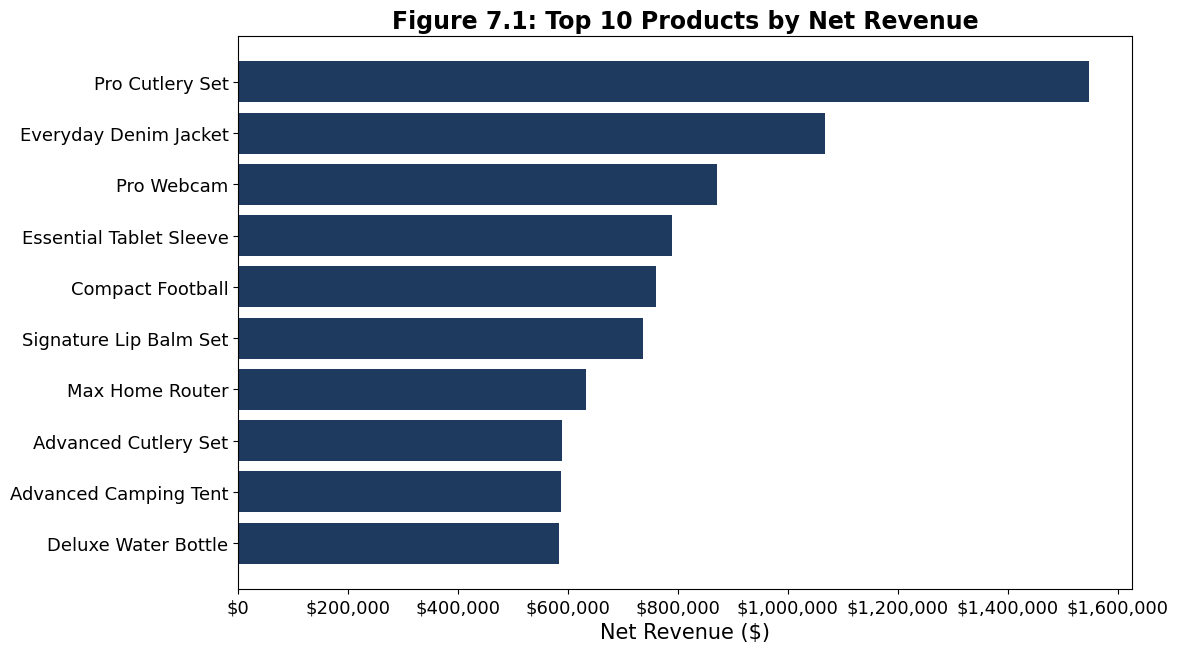

In [4]:
fig, ax = plt.subplots(figsize=FIG_SIZE)
data = top10_revenue.sort_values('net_revenue')
ax.barh(data['product_name'], data['net_revenue'], color=NAVY)
ax.set_xlabel('Net Revenue ($)')
ax.set_title('Figure 7.1: Top 10 Products by Net Revenue', fontsize=17, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
save_fig(fig, 'top10_products_revenue.png')
plt.show()


## Task 4.2 — Underperforming SKUs (Low Margin, Low Volume)

**Method:** A product is flagged "underperforming" if it sits in the **bottom 25% of both**
margin percentage and quantity sold — i.e. it doesn't sell well *and* isn't profitable when it does.
This double-threshold avoids flagging low-volume-but-high-margin niche products, or high-volume
loss leaders that may be strategic.


In [5]:
margin_q25 = product_agg['margin_pct'].quantile(0.25)
qty_q25 = product_agg['quantity_sold'].quantile(0.25)

underperforming = product_agg[
    (product_agg['margin_pct'] <= margin_q25) &
    (product_agg['quantity_sold'] <= qty_q25)
].sort_values('margin_pct')

underperforming_summary = {
    'threshold_margin_pct_q25': round(margin_q25, 2),
    'threshold_quantity_q25': int(qty_q25),
    'flagged_sku_count': int(len(underperforming)),
    'flagged_skus': underperforming.round(2).to_dict(orient='records'),
    'total_revenue_at_risk': round(underperforming['net_revenue'].sum(), 2),
    'generated_at': pd.Timestamp.utcnow().isoformat()
}
save_json(underperforming_summary, 'underperforming_skus.json')
print(f"{len(underperforming)} SKUs flagged as underperforming, "
      f"representing ${underperforming['net_revenue'].sum():,.0f} in net revenue.")
underperforming[['product_name','category','net_revenue','margin_pct','quantity_sold']].head(10)


Saved ../exports/module3/underperforming_skus.json
7 SKUs flagged as underperforming, representing $219,930 in net revenue.


/tmp/ipykernel_578/316818574.py:15: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  'generated_at': pd.Timestamp.utcnow().isoformat()


,product_name,category,net_revenue,margin_pct,quantity_sold
69,Classic Jump Rope,Sports & Outdoors,"95,298.08",-2.97,355
65,Pro Protein Bar Pack,Food & Beverage,"5,860.50",4.08,184
23,Ultra Shampoo,Beauty & Personal Care,"6,299.57",18.86,441
50,Pro Scented Candle,Home & Living,"30,171.46",19.66,266
55,Signature Baseball Cap,Apparel,"27,472.41",20.48,327
35,Plus Trekking Pole,Sports & Outdoors,"14,330.69",20.52,337
44,Lite Cotton T-Shirt,Apparel,"40,497.13",21.05,482


## Task 4.3 — Product Revenue Pareto Curve (80/20 Rule)

**Assertion:** Revenue concentration is expected to broadly follow the Pareto principle — a
minority of SKUs generating the large majority of revenue. We rank products by revenue,
compute the cumulative % of total revenue, and identify the exact number/percentage of SKUs
that account for 80% of revenue.


In [6]:
pareto = product_agg.sort_values('net_revenue', ascending=False).reset_index(drop=True)
pareto['cum_revenue'] = pareto['net_revenue'].cumsum()
pareto['cum_revenue_pct'] = (pareto['cum_revenue'] / pareto['net_revenue'].sum() * 100).round(2)
pareto['product_rank'] = pareto.index + 1
pareto['product_rank_pct'] = (pareto['product_rank'] / len(pareto) * 100).round(2)

skus_for_80pct = int((pareto['cum_revenue_pct'] <= 80).sum() + 1)
pct_of_catalog = round(skus_for_80pct / len(pareto) * 100, 1)

product_pareto = {
    'total_skus': int(len(pareto)),
    'skus_driving_80pct_revenue': skus_for_80pct,
    'pct_of_catalog_driving_80pct_revenue': pct_of_catalog,
    'curve': pareto[['product_rank','product_id','product_name','net_revenue',
                      'cum_revenue_pct']].round(2).to_dict(orient='records'),
    'generated_at': pd.Timestamp.utcnow().isoformat()
}
save_json(product_pareto, 'product_pareto.json')
print(f'{skus_for_80pct} of {len(pareto)} SKUs ({pct_of_catalog}% of catalog) generate 80% of net revenue.')


Saved ../exports/module3/product_pareto.json
29 of 90 SKUs (32.2% of catalog) generate 80% of net revenue.


/tmp/ipykernel_578/1443138539.py:16: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  'generated_at': pd.Timestamp.utcnow().isoformat()


Saved ../exports/module3/product_pareto.png


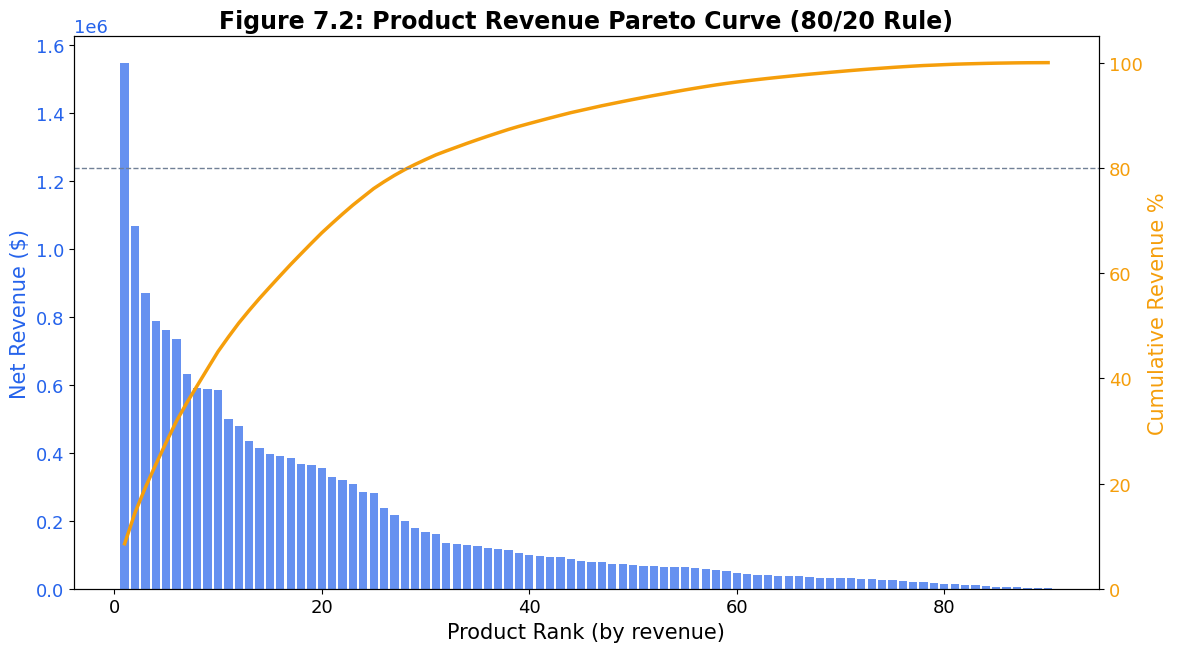

In [7]:
fig, ax1 = plt.subplots(figsize=FIG_SIZE)
ax1.bar(pareto['product_rank'], pareto['net_revenue'], color=BLUE, alpha=0.7)
ax1.set_xlabel('Product Rank (by revenue)')
ax1.set_ylabel('Net Revenue ($)', color=BLUE)
ax1.tick_params(axis='y', labelcolor=BLUE)

ax2 = ax1.twinx()
ax2.plot(pareto['product_rank'], pareto['cum_revenue_pct'], color=AMBER, linewidth=2.5)
ax2.axhline(80, color=SLATE, linestyle='--', linewidth=1)
ax2.set_ylabel('Cumulative Revenue %', color=AMBER)
ax2.tick_params(axis='y', labelcolor=AMBER)
ax2.set_ylim(0, 105)

ax1.set_title('Figure 7.2: Product Revenue Pareto Curve (80/20 Rule)', fontsize=17, fontweight='bold')
plt.tight_layout()
save_fig(fig, 'product_pareto.png')
plt.show()


## Task 4.4 — Category × Channel Cross-Tabulation & Heatmap

**Assertion:** Revenue performance is not uniform across category-channel combinations — some
categories may over-index on a particular channel (e.g. Electronics online, Home & Living via
Dealer), revealing channel specialization worth exploiting or rebalancing.


In [8]:
channel_matrix = pd.pivot_table(
    df, values='net_revenue', index='category', columns='channel',
    aggfunc='sum', fill_value=0
).round(2)

channel_matrix_json = {
    'categories': channel_matrix.index.tolist(),
    'channels': channel_matrix.columns.tolist(),
    'matrix': channel_matrix.values.tolist(),
    'row_totals': channel_matrix.sum(axis=1).round(2).to_dict(),
    'col_totals': channel_matrix.sum(axis=0).round(2).to_dict(),
    'generated_at': pd.Timestamp.utcnow().isoformat()
}
save_json(channel_matrix_json, 'channel_matrix.json')
channel_matrix


Saved ../exports/module3/channel_matrix.json


/tmp/ipykernel_578/1883512461.py:12: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  'generated_at': pd.Timestamp.utcnow().isoformat()


channel,Branch,Dealer,Direct Sales,Online,Partner
category,,,,,
Apparel,"412,792.28","242,583.92","250,023.51","567,144.95","156,305.51"
Beauty & Personal Care,"528,530.41","309,960.90","322,788.00","740,366.42","204,002.87"
Electronics,"1,366,975.52","864,212.98","840,212.12","1,992,868.94","579,143.33"
Food & Beverage,"234,120.67","143,484.47","142,214.54","326,701.13","91,402.76"
Home & Living,"1,032,673.30","598,032.22","612,246.73","1,429,947.90","402,818.90"
Sports & Outdoors,"917,036.22","533,909.27","553,358.77","1,335,158.72","382,784.38"


Saved ../exports/module3/channel_heatmap.png


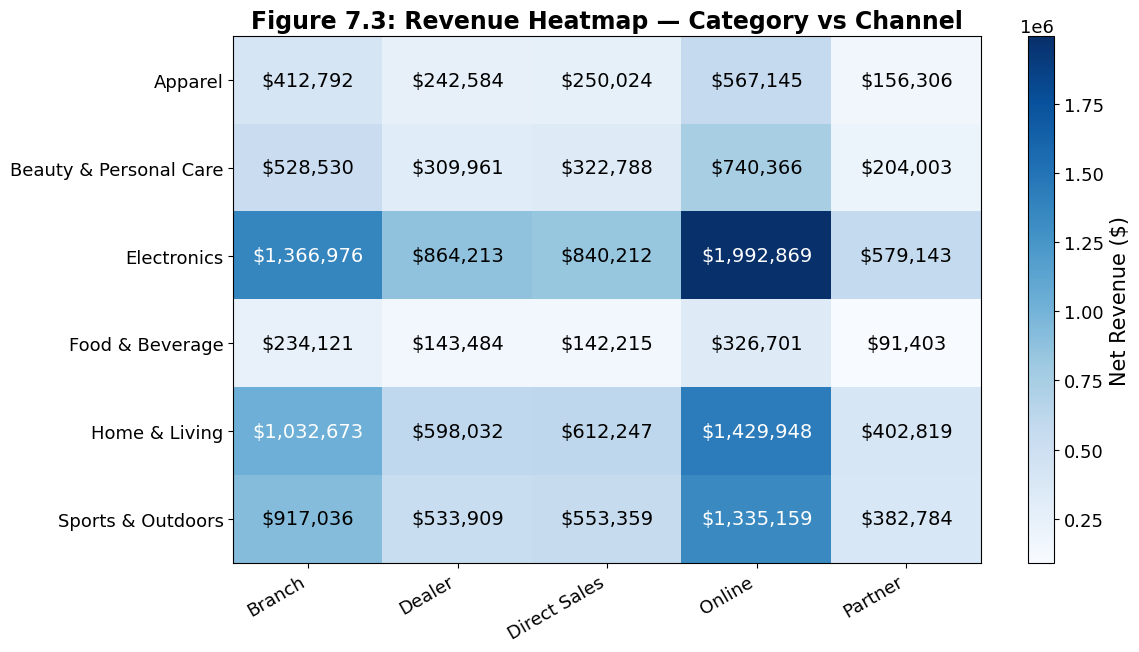

In [9]:
fig, ax = plt.subplots(figsize=FIG_SIZE)
im = ax.imshow(channel_matrix.values, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(channel_matrix.columns)))
ax.set_xticklabels(channel_matrix.columns, rotation=30, ha='right')
ax.set_yticks(range(len(channel_matrix.index)))
ax.set_yticklabels(channel_matrix.index)

for i in range(channel_matrix.shape[0]):
    for j in range(channel_matrix.shape[1]):
        val = channel_matrix.values[i, j]
        color = 'white' if val > channel_matrix.values.max() * 0.5 else 'black'
        ax.text(j, i, f'${val:,.0f}', ha='center', va='center', color=color, fontsize=14)

ax.set_title('Figure 7.3: Revenue Heatmap — Category vs Channel', fontsize=17, fontweight='bold')
fig.colorbar(im, ax=ax, label='Net Revenue ($)')
plt.tight_layout()
save_fig(fig, 'channel_heatmap.png')
plt.show()


## Task 4.5 — Branch Revenue & Margin Performance Tiers

**Method:** Branches are ranked by net revenue and split into three performance tiers
(Top / Mid / Bottom third) using quantile cuts, so the report and app can flag underperforming
locations at a glance.


In [10]:
branch_agg = df.groupby('branch_id', as_index=False).agg(
    net_revenue=('net_revenue', 'sum'),
    gross_margin=('gross_margin', 'sum'),
    transactions=('transaction_id', 'count')
)
branch_agg['margin_pct'] = (branch_agg['gross_margin'] / branch_agg['net_revenue'] * 100).round(2)
branch_agg = branch_agg.sort_values('net_revenue', ascending=False).reset_index(drop=True)
branch_agg['tier'] = pd.qcut(branch_agg['net_revenue'], q=3, labels=['Bottom Tier','Mid Tier','Top Tier'])

branch_matrix = {
    'branches': branch_agg.round(2).to_dict(orient='records'),
    'top_branch': branch_agg.iloc[0]['branch_id'],
    'bottom_branch': branch_agg.iloc[-1]['branch_id'],
    'generated_at': pd.Timestamp.utcnow().isoformat()
}
save_json(branch_matrix, 'branch_matrix.json')
branch_agg


Saved ../exports/module3/branch_matrix.json


/tmp/ipykernel_578/4085627310.py:14: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  'generated_at': pd.Timestamp.utcnow().isoformat()


,branch_id,net_revenue,gross_margin,transactions,margin_pct,tier
0,BR01,"3,250,357.65","1,022,501.42",8950,31.46,Top Tier
1,BR02,"2,664,098.66","819,956.69",7522,30.78,Top Tier
2,BR03,"2,540,622.25","792,623.07",7053,31.20,Top Tier
3,BR04,"2,417,565.75","760,406.05",6374,31.45,Mid Tier
4,BR05,"2,165,589.80","676,589.78",6047,31.24,Mid Tier
5,BR06,"1,847,936.41","572,912.71",5139,31.00,Bottom Tier
6,BR07,"1,826,339.55","577,645.11",4929,31.63,Bottom Tier
7,BR08,"1,401,291.57","439,794.52",3986,31.38,Bottom Tier


Saved ../exports/module3/branch_performance.png


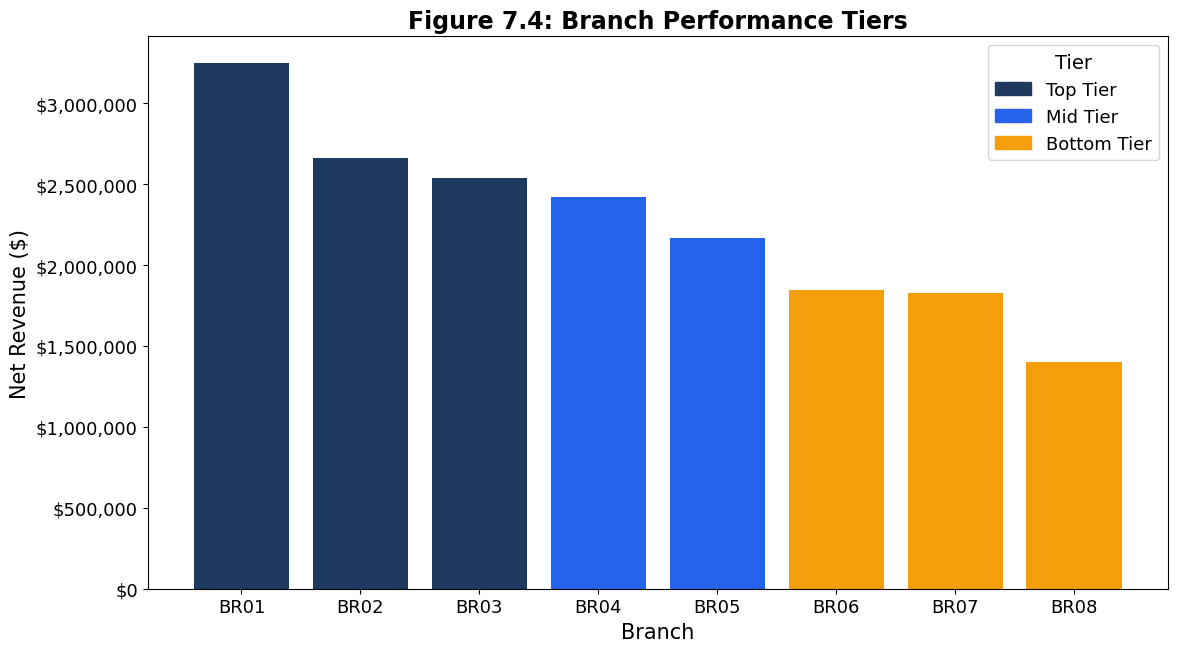

In [11]:
fig, ax = plt.subplots(figsize=FIG_SIZE)
tier_colors = {'Top Tier': NAVY, 'Mid Tier': BLUE, 'Bottom Tier': AMBER}
colors = branch_agg['tier'].map(tier_colors)
ax.bar(branch_agg['branch_id'], branch_agg['net_revenue'], color=colors)
ax.set_xlabel('Branch')
ax.set_ylabel('Net Revenue ($)')
ax.set_title('Figure 7.4: Branch Performance Tiers', fontsize=17, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

handles = [plt.Rectangle((0,0),1,1, color=c) for c in tier_colors.values()]
ax.legend(handles, tier_colors.keys(), title='Tier')
plt.tight_layout()
save_fig(fig, 'branch_performance.png')
plt.show()


## Summary for Report Section 7 (Product & Channel Performance)

Use the printed numbers below directly in the report narrative (Assertion → Evidence →
Interpretation pattern). All JSON/PNG files are now saved to `exports/module3/` for Member D.


In [12]:
print('=== MODULE 3 KEY NUMBERS FOR SECTION 7 ===')
print(f"Total SKUs: {len(product_agg)}")
print(f"Top product by revenue: {top10_revenue.iloc[0]['product_name']} "
      f"(${top10_revenue.iloc[0]['net_revenue']:,.0f})")
print(f"{skus_for_80pct} SKUs ({pct_of_catalog}% of catalog) generate 80% of net revenue")
print(f"{len(underperforming)} SKUs flagged as underperforming "
      f"(${underperforming['net_revenue'].sum():,.0f} revenue at risk)")
print(f"Best branch: {branch_matrix['top_branch']} | Weakest branch: {branch_matrix['bottom_branch']}")
best_combo = channel_matrix.stack().idxmax()
print(f"Strongest category-channel pairing: {best_combo[0]} via {best_combo[1]} "
      f"(${channel_matrix.stack().max():,.0f})")


=== MODULE 3 KEY NUMBERS FOR SECTION 7 ===
Total SKUs: 90
Top product by revenue: Pro Cutlery Set ($1,548,616)
29 SKUs (32.2% of catalog) generate 80% of net revenue
7 SKUs flagged as underperforming ($219,930 revenue at risk)
Best branch: BR01 | Weakest branch: BR08
Strongest category-channel pairing: Electronics via Online ($1,992,869)
